## Загрузка данных

Загружаем необходимые признаки из train и test. `V`-признаки переводим в `float32` для экономии памяти GPU, заранее удаляем признаки с большим количеством пропусков.

In [1]:
# блок импортов
import cudf as cd
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import numpy as np
import pandas as pd

In [2]:
import json

with open("nans.json", "r", encoding="utf-8") as f:
    nans_groups = json.load(f)

In [3]:
cols = [508189, 449124, 460110, 450721, 450909, 508589, 508595, 528353, 528588, 525823, 515614, 551623, 517353, 453249, 552913]
d = [j for row in [nans_groups[f'{i}'] for i in cols] for j in row]

In [4]:
cols_t = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']
cols_v = ['V'+str(x) for x in range(1,340)]; types_v = {}
for c in cols_v: types_v[c] = 'float32' # конвертируем для экономии памяти


train_trans = cd.read_csv(r'../data/raw/train_transaction.csv', usecols=cols_t+['isFraud']+cols_v, dtype=types_v).drop(columns=d)

# test_trans = cd.read_csv(r'../data/raw/test_transaction.csv', usecols=cols_t+cols_v, dtype=types_v).drop(columns=d)

nans_cols = ['279287', '76073', '168969', '77096', '89164', '314', '12']

## Временное разбиение

Сортируем транзакции по `TransactionDT` и выделяем последние 20% данных в `holdout`. Такой split имитирует предсказание будущих транзакций.

In [5]:
train_trans = train_trans.sort_values('TransactionDT').reset_index(drop=True)

holdout_size = 0.2
split_idx = int(len(train_trans) * (1 - holdout_size))

train = train_trans.iloc[:split_idx].copy()
holdout = train_trans.iloc[split_idx:].copy()

del train_trans
gc.collect()

20

## Feature Engineering

`FeatureEngineer` объединяет весь preprocessing в единый pipeline: frequency encoding категориальных признаков, создание временных признаков и `uid`, групповые статистики, признаки отклонения и заполнение пропусков. Параметры преобразований обучаются на train и затем применяются к validation/holdout через `transform()`.

In [6]:
class FeatureEngineer:
    def __init__(self):
        self.pca_groups = {
            "v": ['V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315'],
            **{f"v{i}": nans_groups[col] for i, col in enumerate(nans_cols)}
        }
        self.frequency_columns = []
        self.freq_maps = {}

        self.agg_columns = [
            'D4n',
            'D10n',
            'D15n',
            'TransactionAmt',
            'dist1'
        ]

        self.uid_stats = None
        self.agg_stats = {}
        self.agg_global_stats = {}

        self.number_columns = []
        self.imputer = None

        self.pca_processors = {}

    
    def _fit_frequency_encoding(self, X):
        self.frequency_columns = (X.select_dtypes(include=['object', 'string']).columns.tolist())
        
        for col in self.frequency_columns:
            self.freq_maps[col] = (X[col].value_counts(normalize=True).to_dict())
        return self

    
    def _apply_frequency_encoding(self, X):
        for col in self.frequency_columns:
            X[f"{col}_freq"] = (X[col].map(self.freq_maps[col]).fillna(0))

        X.drop(columns=self.frequency_columns, inplace=True)

        X['D1n'] = np.floor(X.TransactionDT / (24*60*60)) - X.D1
        X['D4n'] = np.floor(X.TransactionDT / (24*60*60)) - X.D4
        X['D10n'] = np.floor(X.TransactionDT / (24*60*60)) - X.D10
        X['D15n'] = np.floor(X.TransactionDT / (24*60*60)) - X.D15
        X['uid'] = X.card1.astype(str)+'_'+X.addr1.astype(str)+'_'+X.D1n.astype(str)
        return X


    def _fit_advanced_aggregations(self, X):
        self.agg_keys = {
            'card1': ['card1'],
            'card1_day': ['card1', 'D1n'],
            'card_addr': ['uid']
        }
    

        for group_name, keys in self.agg_keys.items():
            agg = X.groupby(keys)[self.agg_columns].agg(['count', 'mean', 'std'])
            agg.columns = [f'{col}_{stat}_{group_name}' for col, stat in agg.columns]
            
            for col in self.agg_columns:
                self.agg_global_stats[f"{col}_count_{group_name}"] = 0
                self.agg_global_stats[f"{col}_mean_{group_name}"] = X[col].mean()
                self.agg_global_stats[f"{col}_std_{group_name}"] = X[col].std()
                        
            self.agg_stats[group_name] = agg
            
        return self


    def _apply_advanced_aggregations(self, X):
        X['row_id'] = cp.arange(len(X))
        
        for group_name, keys in self.agg_keys.items():
            agg_df = self.agg_stats[group_name]
            
            X = X.merge(agg_df, left_on=keys, right_index=True, how='left', sort=False)
            for col in self.agg_stats[group_name]:
                X[col] = X[col].fillna(self.agg_global_stats[col])

        X = X.sort_values('row_id').drop(columns=['row_id', 'uid']) # восстанавливаем исходный порядок и удаляем технические столбцы
        
        X['Amt_dev_card1'] = (X['TransactionAmt'] - X['TransactionAmt_mean_card1']) / (X['TransactionAmt_std_card1'] + 1e-5) # отклонение суммы от среднего по карте
        X['Amt_dev_card1_day'] = (X['TransactionAmt'] - X['TransactionAmt_mean_card1_day']) / (X['TransactionAmt_std_card1_day'] + 1e-5) # отклонение суммы от среднего по карте за день
        X['dist_dev_card1'] = (X['dist1'] - X['dist1_mean_card1']) / (X['dist1_std_card1'] + 1e-5) # отклонение расстояния

        return X
        
    
    def _fit_imputer(self, X):
        from sklearn.impute import SimpleImputer
        self.number_columns = X.select_dtypes(include=['number']).columns.to_list()
        self.imputer = SimpleImputer(strategy='median')
        self.imputer.fit(X[self.number_columns].to_numpy())
        return self

    
    def _apply_imputer(self, X):
        X[self.number_columns] = self.imputer.transform(X[self.number_columns].to_numpy())
        return X

    
    def fit(self, X):
        X = X.copy()
        self._fit_frequency_encoding(X)
        X = self._apply_frequency_encoding(X)
    
        self._fit_advanced_aggregations(X)
        X = self._apply_advanced_aggregations(X)
    
        self._fit_imputer(X)
        X = self._apply_imputer(X)

        return self

    
    def transform(self, X):
        X = X.copy()
        X = self._apply_frequency_encoding(X)
        
        X = self._apply_advanced_aggregations(X)
        
        X = self._apply_imputer(X)
        
        return X

    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

## Time Series Cross-Validation

Используем `TimeSeriesSplit`, чтобы validation всегда находилась после train по времени. Это позволяет сохранить временную структуру данных при оценке модели.

In [7]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)

folds = list(tscv.split(train))

## Подбор гиперпараметров

С помощью Optuna подбираем `max_depth`, `n_estimators` и `learning_rate` для XGBoost. Для каждого набора параметров рассчитываем средний ROC-AUC на временных folds.

P.S.: обучить LightGBM на CUDA не удалось ввиду технических ошибок. Решение для устранения проблемы пока не найдено. Также не удалось запустить CatBoost в Optuna ввиду неправильного разделения потоков, решение пока не найдено.

In [56]:
import optuna
from sklearn.metrics import roc_auc_score
import xgboost as xgb

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'n_estimators': trial.suggest_int('n_estimators', 1200, 1800, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.075, 0.125, log=True),
    }

    scores = []

    for train_idx, val_idx in folds:

        train_fold = train.iloc[train_idx].copy()
        val_fold = train.iloc[val_idx].copy()

        y_train = train_fold.pop('isFraud')
        y_val = val_fold.pop('isFraud')

        fe = FeatureEngineer() #обрабатываем каждый временной фолд классом FE

        X_train = fe.fit_transform(train_fold)
        X_val = fe.transform(val_fold)

        pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
        
        model = xgb.XGBClassifier(**params, tree_method='hist', device='cuda', random_state=42, scale_pos_weight=pos_weight, eval_metric='auc', verbosity=0)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict_proba(X_val)[:, 1]

        score = roc_auc_score(y_val.to_numpy(), preds)
        scores.append(score)

    return np.mean(scores)
    
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(f'Time CV best parameters: {study.best_params}, Best ROC-AUC CV value: {study.best_value}')

[I 2026-08-27 00:48:52,987] A new study created in memory with name: no-name-ab0ea996-61fd-430e-ba65-1a2dd447003f
[I 2026-08-27 00:51:59,762] Trial 0 finished with value: 0.9006386848576335 and parameters: {'max_depth': 10, 'n_estimators': 1400, 'learning_rate': 0.07823914602705548}. Best is trial 0 with value: 0.9006386848576335.
[I 2026-08-27 00:56:26,076] Trial 1 finished with value: 0.9058546269098678 and parameters: {'max_depth': 13, 'n_estimators': 1800, 'learning_rate': 0.08709632586563251}. Best is trial 1 with value: 0.9058546269098678.
[I 2026-08-27 00:59:18,416] Trial 2 finished with value: 0.8847378456814381 and parameters: {'max_depth': 7, 'n_estimators': 1800, 'learning_rate': 0.08018239068794276}. Best is trial 1 with value: 0.9058546269098678.
[I 2026-08-27 01:01:37,244] Trial 3 finished with value: 0.8842702325068483 and parameters: {'max_depth': 7, 'n_estimators': 1250, 'learning_rate': 0.08516033746583318}. Best is trial 1 with value: 0.9058546269098678.
[I 2026-08-2

Time CV best parameters: {'max_depth': 15, 'n_estimators': 1600, 'learning_rate': 0.09667068828889584}, Best ROC-AUC CV value: 0.9077548008331646


In [8]:
# best_params = study.best_params
best_params = {'max_depth': 15, 'n_estimators': 1600, 'learning_rate': 0.09667068828889584}

## Финальное обучение

С лучшими параметрами обучаем XGBoost, LightGBM и CatBoost на всей train-части и оцениваем качество на отложенном временном `holdout`.

In [9]:
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

train_X = train.drop(columns='isFraud')
train_y = train['isFraud']

holdout_X = holdout.drop(columns='isFraud')
holdout_y = holdout['isFraud']

fe = FeatureEngineer()

X_train = fe.fit_transform(train_X)
X_holdout = fe.transform(holdout_X)

del train_X, holdout_X
gc.collect()

0

In [10]:
from sklearn.metrics import roc_auc_score

xgb_model = xgb.XGBClassifier(**best_params, tree_method='hist', device='cuda', random_state=42)

xgb_model.fit(X_train, train_y)
xgb_preds = xgb_model.predict_proba(X_holdout)[:, 1]

xgb_score = roc_auc_score(holdout_y.to_numpy(), xgb_preds)
print(xgb_score)

0.9280731059182297


In [11]:
gc.collect()

2

In [12]:
lgb_model = lgb.LGBMClassifier(device='cpu', random_state=42, verbose=-1, **best_params)

lgb_model.fit(X_train.to_numpy(), train_y.to_numpy())
lgb_preds = lgb_model.predict_proba(X_holdout.to_numpy())[:, 1]

lgb_score = roc_auc_score(holdout_y.to_numpy(), lgb_preds)
print(lgb_score)

0.9178301448422173


In [13]:
gc.collect()

0

In [16]:
cb_model = cb.CatBoostClassifier(iterations=1600, depth=6, learning_rate=0.097, thread_count=-1, task_type="CPU", random_state=42, verbose=0)

cb_model.fit(X_train.to_numpy(), train_y.to_numpy(), eval_set=(X_holdout.to_numpy(), holdout_y.to_numpy()), early_stopping_rounds=400, use_best_model=True)
cb_preds = cb_model.predict_proba(X_holdout.to_numpy())[:, 1]

cb_score = roc_auc_score(holdout_y.to_numpy(), cb_preds)
print(cb_score)

0.8998874536475355


## Blending

Объединяем предсказания трёх моделей с весами `0.5 / 0.35 / 0.15` и рассчитываем итоговый ROC-AUC.

In [26]:
blend_preds = xgb_preds * 0.5 + lgb_preds * 0.35 + cb_preds * 0.15
blend_score = roc_auc_score(holdout_y.to_numpy(), blend_preds)

## Сравнение моделей

Рассчитываем ROC-AUC для каждой модели на holdout и сравниваем их качество.

In [33]:
result = cd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Blending'], 
    'ROC-AUC': [xgb_score, lgb_score, cb_score, blend_score]
})

display(result)

,Model,ROC-AUC
0,XGBoost,0.928073
1,LightGBM,0.917830
2,CatBoost,0.899887
3,Blending,0.926624


## MLP

Дополнительно обучаем полносвязную нейронную сеть на GPU. Используем BatchNorm, Dropout и `BCEWithLogitsLoss` с `pos_weight` для учёта дисбаланса классов.

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from cuml.preprocessing import StandardScaler


class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(64, 1) # Выход без сигмоиды (используем BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.network(x)


def train_mlp(X_train, y_train, X_val, y_val, epochs=15, lr=0.001, batch_size=4096):
    device = 'cuda'
    
    # Конвертация из cudf/cupy в torch tensors
    X_tr = torch.tensor(X_train.to_numpy(), dtype=torch.float32, device=device)
    y_tr = torch.tensor(y_train.to_numpy(), dtype=torch.float32, device=device).unsqueeze(1)
    X_va = torch.tensor(X_val.to_numpy(), dtype=torch.float32, device=device)
    y_va = torch.tensor(y_val.to_numpy(), dtype=torch.float32, device=device).unsqueeze(1)

    model = FraudMLP(input_dim=X_tr.shape[1]).to(device)
    
    # pos_weight для борьбы с дисбалансом классов
    pos_weight = torch.tensor([(y_tr.shape[0] - y_tr.sum()) / y_tr.sum()], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    train_dataset = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    history = {'train_loss': [], 'val_auc': []}
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        history['train_loss'].append(epoch_loss / len(train_loader))
        
        # Валидация
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va)
            val_probs = torch.sigmoid(val_logits).cpu().numpy()
            val_auc = roc_auc_score(y_va.cpu().numpy(), val_probs)
            
        history['val_auc'].append(val_auc)
        
    return history, model


def plot_learning_curves(history, fold_num=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    title_prefix = f"Fold {fold_num} - " if fold_num is not None else ""
    
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.set_title(f'{title_prefix}Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('BCEWithLogitsLoss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    ax2.plot(history['val_auc'], label='Val ROC-AUC', color='orange')
    ax2.set_title(f'{title_prefix}Validation ROC-AUC')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

## Обучение MLP

MLP обучается отдельно на каждом временном fold. Для каждого fold сохраняем training loss и validation ROC-AUC.

## Learning Curves

Визуализируем изменение `Training Loss` и `Validation ROC-AUC` по эпохам, чтобы оценить процесс обучения и возможное переобучение.

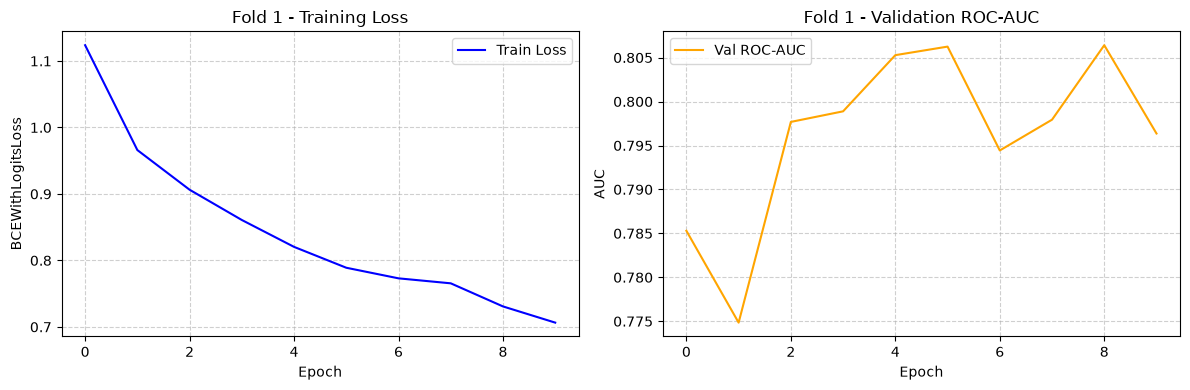

Final MLP Val AUC: 0.7964


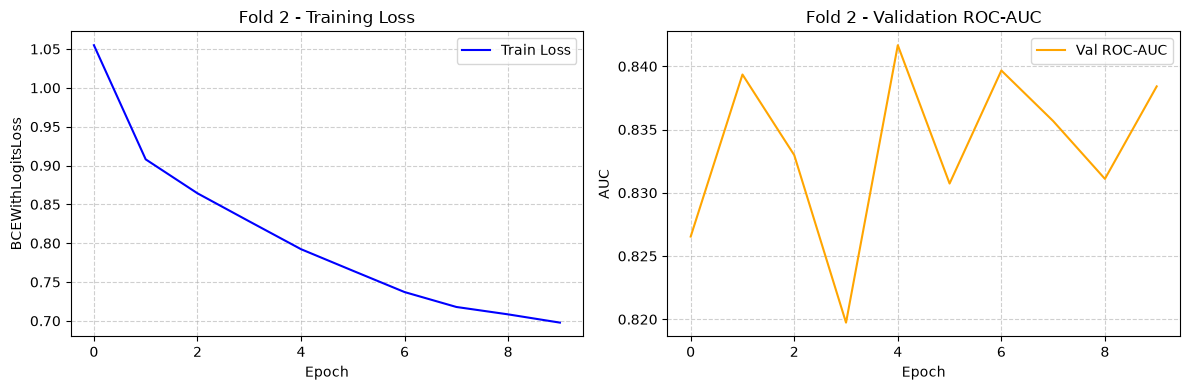

Final MLP Val AUC: 0.8384


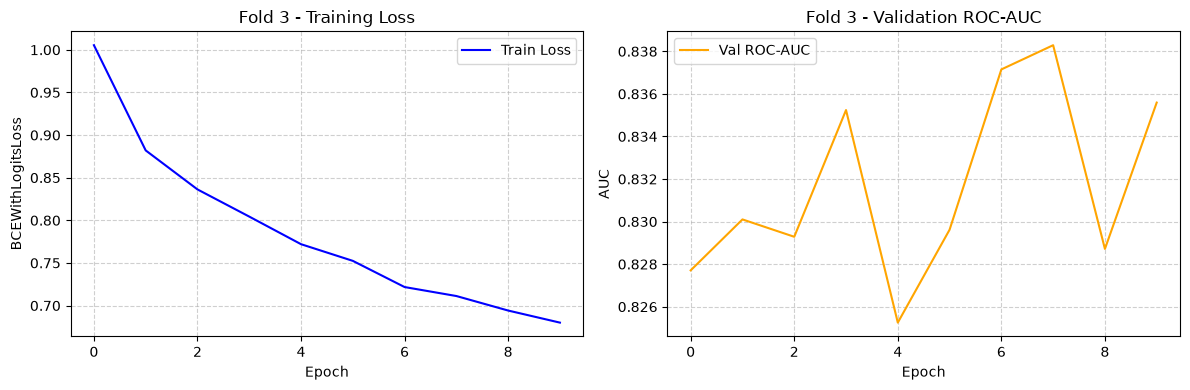

Final MLP Val AUC: 0.8356


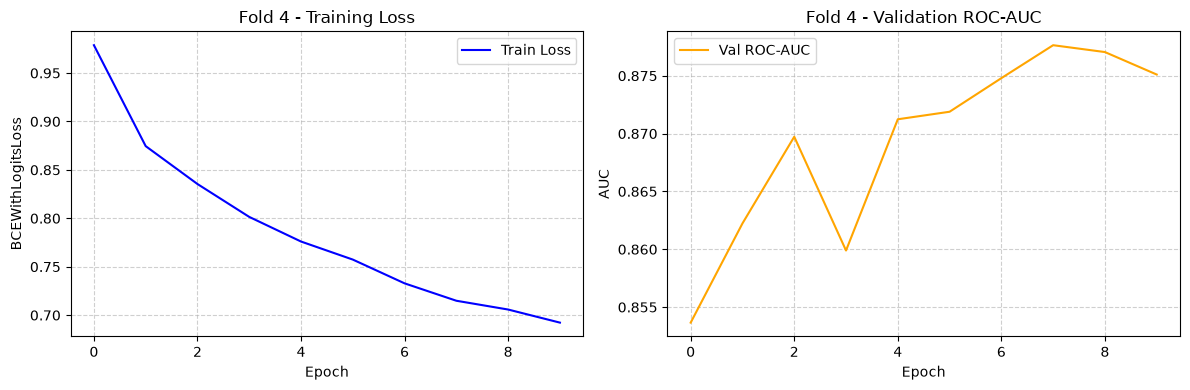

Final MLP Val AUC: 0.8751


In [35]:
for fold_num, (train_idx, val_idx) in enumerate(folds, start=1):
    scaler = StandardScaler()

    train_fold = train.iloc[train_idx].copy()
    val_fold = train.iloc[val_idx].copy()

    y_train = train_fold.pop('isFraud')
    y_val = val_fold.pop('isFraud')

    fe = FeatureEngineer() #обрабатываем каждый временной фолд классом FE

    X_train = fe.fit_transform(train_fold)
    X_val = fe.transform(val_fold)

    del train_fold, val_fold
    gc.collect()
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    del X_train, X_val
    gc.collect()

    history, mlp_model = train_mlp(X_train_scaled, y_train, X_val_scaled, y_val, epochs=10)
    
    plot_learning_curves(history, fold_num=fold_num)
    
    final_auc = history['val_auc'][-1]

    del X_train_scaled, X_val_scaled, y_train, y_val
    del mlp_model, history, scaler
    
    torch.cuda.empty_cache()
    gc.collect()
    
    print(f"Final MLP Val AUC: {final_auc:.4f}")

# Kaggle Submission

In [40]:
test_trans = cd.read_csv(r'../data/raw/test_transaction.csv', usecols=cols_t+cols_v, dtype=types_v).drop(columns=d)

train_X = train.drop(columns='isFraud')

fe = FeatureEngineer()

X_train = fe.fit_transform(train_X)
X_test = fe.transform(test_trans)

sample_df = pd.read_csv(r'../data/final/sample_submission.csv')
sample_df['isFraud'] = xgb_model.predict_proba(X_test)[:, 1] * 0.5 + lgb_model.predict_proba(X_test.to_numpy())[:, 1] * 0.35 + cb_model.predict_proba(X_test.to_numpy())[:, 1] * 0.15

sample_df.to_csv('../data/final/blending_w.csv', index=False)